In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Load data
df_customers = pd.read_csv('../data/saas_customers.csv', 
                           parse_dates=['signup_date', 'churn_date'])
df_monthly = pd.read_csv('../data/saas_monthly.csv')

print("Customers:", df_customers.shape)
print("Monthly:", df_monthly.shape)
df_monthly.head()

Customers: (515, 7)
Monthly: (48, 6)


,month,active_customers,new_customers,churned_customers,mrr,churn_rate
0,2021-01,5,5,0,555,0.00
1,2021-01,8,5,2,712,25.00
2,2021-03,13,5,0,1267,0.00
3,2021-04,17,7,3,1793,17.65
4,2021-05,24,9,2,2336,8.33


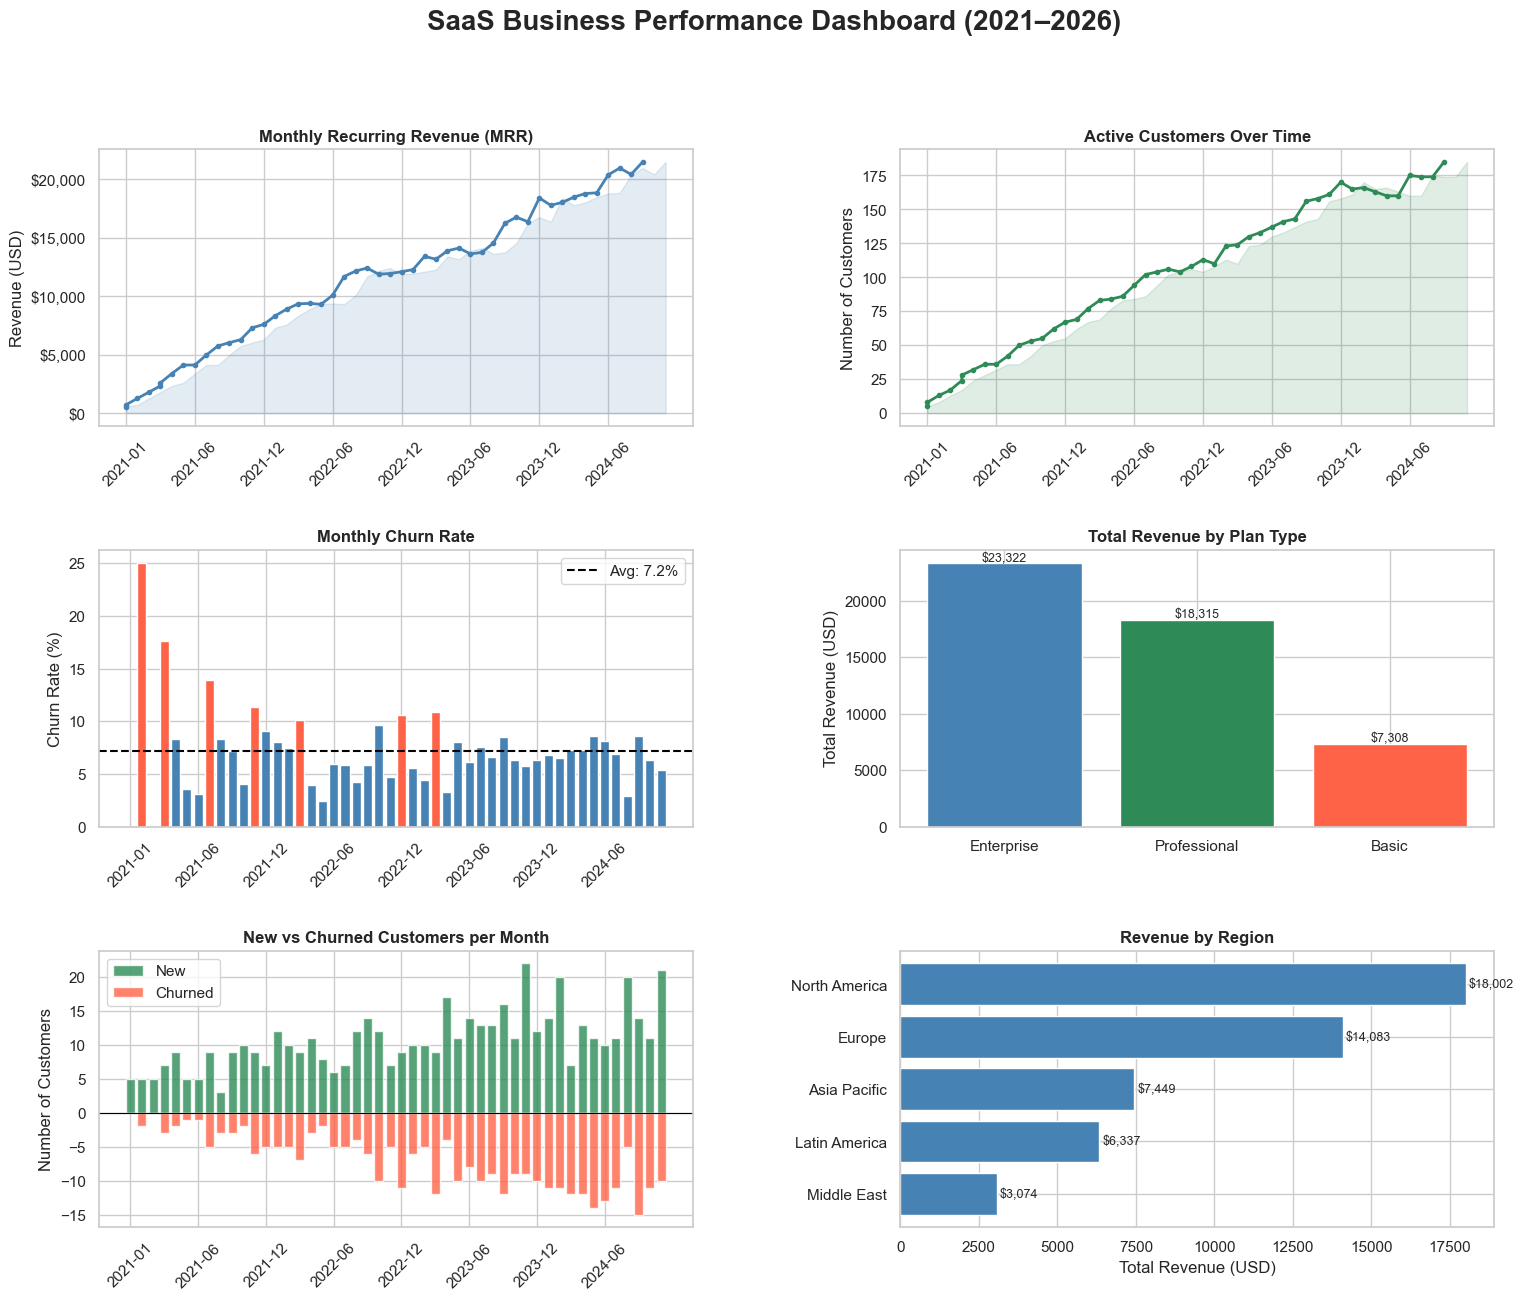

Dashboard saved!


In [4]:
# Create figure with 6 subplots in a 3x2 grid
fig = plt.figure(figsize=(18, 14))
fig.suptitle('SaaS Business Performance Dashboard (2021–2026)', 
             fontsize=20, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: MRR Trend ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_monthly['month'], df_monthly['mrr'], 
         color='steelblue', linewidth=2, marker='o', markersize=3)
ax1.fill_between(range(len(df_monthly)), df_monthly['mrr'], 
                 alpha=0.15, color='steelblue')
ax1.set_title('Monthly Recurring Revenue (MRR)', fontweight='bold')
ax1.set_ylabel('Revenue (USD)')
ax1.set_xticks(range(0, len(df_monthly), 6))
ax1.set_xticklabels(df_monthly['month'][::6], rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# ── Chart 2: Active Customers ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_monthly['month'], df_monthly['active_customers'],
         color='seagreen', linewidth=2, marker='o', markersize=3)
ax2.fill_between(range(len(df_monthly)), df_monthly['active_customers'],
                 alpha=0.15, color='seagreen')
ax2.set_title('Active Customers Over Time', fontweight='bold')
ax2.set_ylabel('Number of Customers')
ax2.set_xticks(range(0, len(df_monthly), 6))
ax2.set_xticklabels(df_monthly['month'][::6], rotation=45)

# ── Chart 3: Churn Rate ──────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors_churn = ['tomato' if x > 10 else 'steelblue' 
                for x in df_monthly['churn_rate']]
ax3.bar(range(len(df_monthly)), df_monthly['churn_rate'], 
        color=colors_churn, edgecolor='white')
ax3.axhline(y=df_monthly['churn_rate'].mean(), color='black',
            linestyle='--', linewidth=1.5,
            label=f"Avg: {df_monthly['churn_rate'].mean():.1f}%")
ax3.set_title('Monthly Churn Rate', fontweight='bold')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_xticks(range(0, len(df_monthly), 6))
ax3.set_xticklabels(df_monthly['month'][::6], rotation=45)
ax3.legend()

# ── Chart 4: Revenue by Plan ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
plan_revenue = df_customers.groupby('plan')['monthly_price'].sum().reset_index()
plan_revenue.columns = ['plan', 'total_revenue']
plan_revenue = plan_revenue.sort_values('total_revenue', ascending=False)

bars = ax4.bar(plan_revenue['plan'], plan_revenue['total_revenue'],
               color=['steelblue', 'seagreen', 'tomato'], edgecolor='white')
for bar, val in zip(bars, plan_revenue['total_revenue']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${val:,.0f}', ha='center', fontsize=9)
ax4.set_title('Total Revenue by Plan Type', fontweight='bold')
ax4.set_ylabel('Total Revenue (USD)')

# ── Chart 5: New vs Churned Customers ───────────────
ax5 = fig.add_subplot(gs[2, 0])
x = range(len(df_monthly))
ax5.bar(x, df_monthly['new_customers'], 
        label='New', color='seagreen', alpha=0.8)
ax5.bar(x, -df_monthly['churned_customers'], 
        label='Churned', color='tomato', alpha=0.8)
ax5.axhline(y=0, color='black', linewidth=0.8)
ax5.set_title('New vs Churned Customers per Month', fontweight='bold')
ax5.set_ylabel('Number of Customers')
ax5.set_xticks(range(0, len(df_monthly), 6))
ax5.set_xticklabels(df_monthly['month'][::6], rotation=45)
ax5.legend()

# ── Chart 6: Revenue by Region ───────────────────────
ax6 = fig.add_subplot(gs[2, 1])
region_rev = df_customers.groupby('region')['monthly_price'].sum().reset_index()
region_rev = region_rev.sort_values('monthly_price', ascending=True)
ax6.barh(region_rev['region'], region_rev['monthly_price'],
         color='steelblue', edgecolor='white')
for i, val in enumerate(region_rev['monthly_price']):
    ax6.text(val + 100, i, f'${val:,.0f}', va='center', fontsize=9)
ax6.set_title('Revenue by Region', fontweight='bold')
ax6.set_xlabel('Total Revenue (USD)')

plt.savefig('../images/saas_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")